In [185]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [186]:
# all notes for representing normal sin waves and guassian(noisy) ones: (just as a reminder)
#  time formula, starts from 0 upto 2pi (whole cycle, its in rad not sec cuz it's sin wave) and sampling of 100 points so it looks smooth, time is always x label in the plot
# now we produce y which uses the formula y = sin(2pi * frequency * time) so i decide fequency as 1 cuz its cycles per second
# we find y for a pure sin wave, for noisy one we don't need it
# y = np.sin(2 * np.pi * 1 * time)
#guassian nomal is used to add the noise -> normally distrubuted means most of the data are in the center
# loc means most of the errors are at the center, scale means std
# Using the 68-95-99.7 rule:68% of the time, Python will pick a noise value between -0.3 +0.3. (Minor, subtle jitter).
# 95% of the time, Python will pick a noise value between -0.6 and +0.6. 
# (Moderate spikes).Only 0.3% of the time will it pick something larger than 0.9. (An extreme, rare outlier spike). thats y we piacked 0.3 scale cuz outlier is a loud noise
# now for visuaalization, this is for normal sin wave
#plt.plot(time, y, color = 'blue')
# degrees describe how overfit it is, 1 = underfit, 4 = perfect, 15 = overfit. we import polynomialfetures for it
# for diff degrees like 1,4,15 we don't put on a single value of y instead we make y smooth in the curve since it'll be diff in each turn (keep in mind sampling: x = y)
# x same, y= 0.5 * x**3 - x + np.random.normal(mean, std, sampling) 

In [187]:
time = np.linspace(0, 2*np.pi, 100)
pure_sine = np.sin(time) # means predicted y too

In [188]:
time

array([0.        , 0.06346652, 0.12693304, 0.19039955, 0.25386607,
       0.31733259, 0.38079911, 0.44426563, 0.50773215, 0.57119866,
       0.63466518, 0.6981317 , 0.76159822, 0.82506474, 0.88853126,
       0.95199777, 1.01546429, 1.07893081, 1.14239733, 1.20586385,
       1.26933037, 1.33279688, 1.3962634 , 1.45972992, 1.52319644,
       1.58666296, 1.65012947, 1.71359599, 1.77706251, 1.84052903,
       1.90399555, 1.96746207, 2.03092858, 2.0943951 , 2.15786162,
       2.22132814, 2.28479466, 2.34826118, 2.41172769, 2.47519421,
       2.53866073, 2.60212725, 2.66559377, 2.72906028, 2.7925268 ,
       2.85599332, 2.91945984, 2.98292636, 3.04639288, 3.10985939,
       3.17332591, 3.23679243, 3.30025895, 3.36372547, 3.42719199,
       3.4906585 , 3.55412502, 3.61759154, 3.68105806, 3.74452458,
       3.8079911 , 3.87145761, 3.93492413, 3.99839065, 4.06185717,
       4.12532369, 4.1887902 , 4.25225672, 4.31572324, 4.37918976,
       4.44265628, 4.5061228 , 4.56958931, 4.63305583, 4.69652

In [189]:
time.shape

(100,)

In [190]:
# added this block to add noise since the common sin wave is pure unlike the requirment
noise = np.random.normal(loc = 0, scale = 0.3, size = 100 )  #same size as x
noisy_sine = pure_sine + noise

In [191]:
noisy_sine

array([-0.42461122, -0.06276968,  0.0237781 , -0.05143194,  0.20276227,
        0.4332487 ,  0.93751823,  0.48216826,  0.56346185,  0.51830704,
        0.01727656,  0.63483345,  0.70814807,  1.47356434,  0.71843817,
        0.90504015,  0.8393119 ,  0.53084995,  1.25247884,  1.15972777,
        1.19221183,  0.69899533,  1.40564605,  0.57328315,  1.17492447,
        1.65701082,  0.69969388,  0.81993212,  1.00869786,  0.81279946,
        0.47980179,  0.94292319,  0.57730266,  1.00810313,  0.55674258,
        1.26074216,  0.52077359,  0.61607572,  0.91082417,  0.24889969,
        0.63529784,  0.90582022, -0.02401845,  0.45632069,  0.41998498,
        0.51627942, -0.15077468, -0.23813559,  0.25163851,  0.12082334,
        0.04341992,  0.00887842, -0.36200881, -0.15063442, -0.19381081,
       -0.55632557,  0.15880182, -0.31607665, -0.87106844, -0.37009378,
       -0.91056349, -0.43064362, -0.3651155 , -1.00195427, -0.506749  ,
       -0.70873558, -0.61940736, -0.32695588, -0.99597073, -1.17

In [192]:
np.random.seed(42) #gives the same output for every time u run it
y_noisy = np.sin(2 * np.pi * time) + np.random.normal(0, 0.4, 100)
x_smooth = np.linspace(0,2*np.pi,200) # more sampling than x
y_smooth = np.sin(x_smooth)

In [193]:
y_smooth

array([ 0.00000000e+00,  3.15685498e-02,  6.31056313e-02,  9.45798078e-02,
        1.25959705e-01,  1.57214043e-01,  1.88311666e-01,  2.19221577e-01,
        2.49912962e-01,  2.80355229e-01,  3.10518032e-01,  3.40371303e-01,
        3.69885285e-01,  3.99030558e-01,  4.27778068e-01,  4.56099159e-01,
        4.83965601e-01,  5.11349616e-01,  5.38223906e-01,  5.64561683e-01,
        5.90336692e-01,  6.15523241e-01,  6.40096223e-01,  6.64031143e-01,
        6.87304143e-01,  7.09892022e-01,  7.31772266e-01,  7.52923064e-01,
        7.73323331e-01,  7.92952733e-01,  8.11791702e-01,  8.29821460e-01,
        8.47024034e-01,  8.63382275e-01,  8.78879879e-01,  8.93501396e-01,
        9.07232251e-01,  9.20058757e-01,  9.31968129e-01,  9.42948495e-01,
        9.52988909e-01,  9.62079363e-01,  9.70210796e-01,  9.77375101e-01,
        9.83565137e-01,  9.88774735e-01,  9.92998700e-01,  9.96232822e-01,
        9.98473878e-01,  9.99719634e-01,  9.99968847e-01,  9.99221269e-01,
        9.97477646e-01,  

In [194]:
y_smooth.shape

(200,)

In [195]:
x_smooth

array([0.        , 0.0315738 , 0.06314759, 0.09472139, 0.12629518,
       0.15786898, 0.18944277, 0.22101657, 0.25259036, 0.28416416,
       0.31573796, 0.34731175, 0.37888555, 0.41045934, 0.44203314,
       0.47360693, 0.50518073, 0.53675452, 0.56832832, 0.59990211,
       0.63147591, 0.66304971, 0.6946235 , 0.7261973 , 0.75777109,
       0.78934489, 0.82091868, 0.85249248, 0.88406627, 0.91564007,
       0.94721387, 0.97878766, 1.01036146, 1.04193525, 1.07350905,
       1.10508284, 1.13665664, 1.16823043, 1.19980423, 1.23137803,
       1.26295182, 1.29452562, 1.32609941, 1.35767321, 1.389247  ,
       1.4208208 , 1.45239459, 1.48396839, 1.51554218, 1.54711598,
       1.57868978, 1.61026357, 1.64183737, 1.67341116, 1.70498496,
       1.73655875, 1.76813255, 1.79970634, 1.83128014, 1.86285394,
       1.89442773, 1.92600153, 1.95757532, 1.98914912, 2.02072291,
       2.05229671, 2.0838705 , 2.1154443 , 2.14701809, 2.17859189,
       2.21016569, 2.24173948, 2.27331328, 2.30488707, 2.33646

In [196]:
x_smooth.shape

(200,)

In [197]:
degrees = [1,4,15]

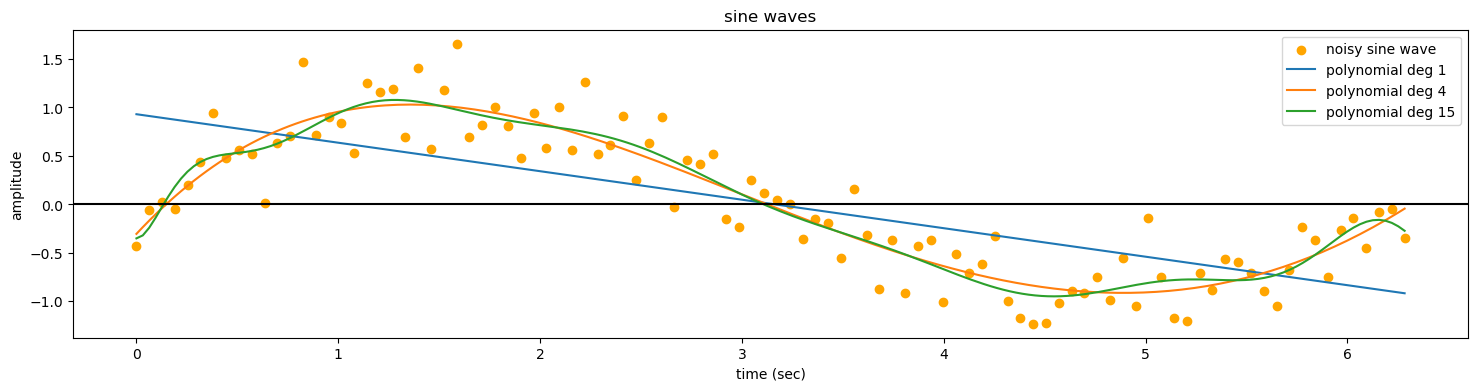

In [198]:
plt.figure(figsize=(18,4))
#plt.plot not here cuz many deg
plt.scatter(time, noisy_sine, label = 'noisy sine wave', color = 'orange') #using scatter plo cuz it's spread out dots, so not to connect them
for degree in degrees:
    #training on raw data
    co_ef= np.polyfit(time, noisy_sine, deg=degree)
    model = np.poly1d(co_ef)
    y_smooth_predict = model(x_smooth)
    plt.plot(x_smooth, y_smooth_predict, label= f'polynomial deg {degree}') #don't mention color here, all will be the same, hard to tell apart
plt.title("sine waves")
plt.xlabel('time (sec)')
plt.ylabel('amplitude')
plt.axhline(0, color ='black')
plt.legend() #adds an explanation, which line is which
plt.show()

In [199]:
#import train_test_split for dividing inti training and validation then import MSE (mean squared error)
#time_train, time_val, y_noisy_train, y_noisy_val = train_test_split(time.reshape(-1,1), y_noisy, test_size=0.2, random_state=42)
time_train = time[:80].reshape(-1, 1)
y_noisy_train = y_noisy[:80]

time_val = time[80:].reshape(-1, 1)
y_noisy_val = y_noisy[80:]

train_error, validation_error = [], []

In [200]:
train_error, validation_error = [], []
degrees = range(1,16)

In [201]:
for deg in degrees:
    model1 = make_pipeline(PolynomialFeatures(deg), StandardScaler(), LinearRegression()) # the graph of validation error was falling after a certain point bcz of math instability so had to add the scalar
    model1.fit(time_train, y_noisy_train)
    train_error.append(mean_squared_error(y_noisy_train, model1.predict(time_train)))
    validation_error.append (mean_squared_error(y_noisy_val,model1.predict(time_val)))

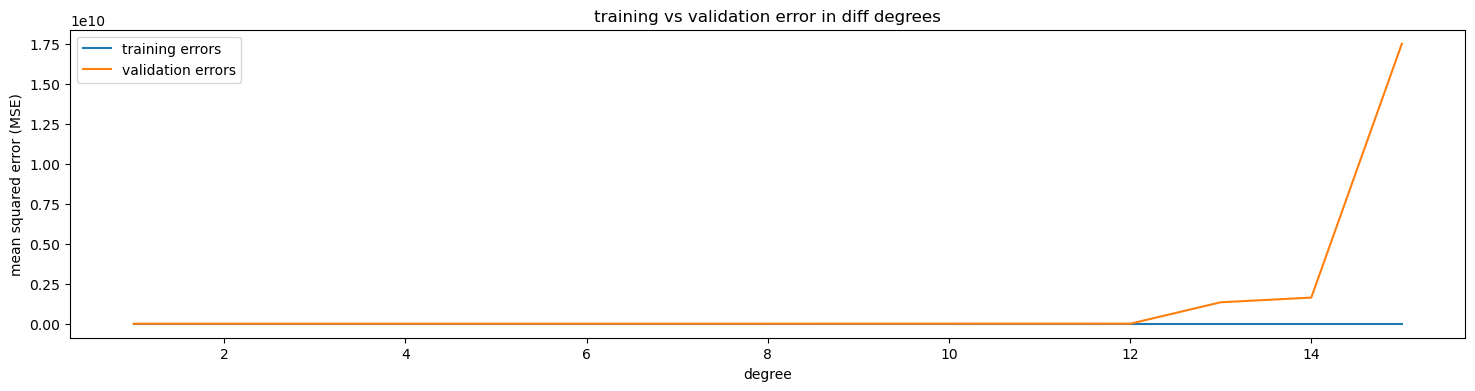

In [202]:
plt.figure(figsize=(18,4))
plt.plot(degrees, train_error, label="training errors")
plt.plot(degrees, validation_error, label="validation errors")
plt.title("training vs validation error in diff degrees")
plt.xlabel("degree")
plt.ylabel("mean squared error (MSE)")
plt.legend()
plt.show()